In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
from matplotlib import pyplot as plt 

In [4]:
df = sns.load_dataset('iris')

In [6]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['species'] = label_encoder.fit_transform(df['species'])

In [9]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [13]:
# removing 1 class and also taking just 2 features 
df = df[df['species'] != 0][['sepal_width' , 'petal_length' , 'species']]

In [14]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


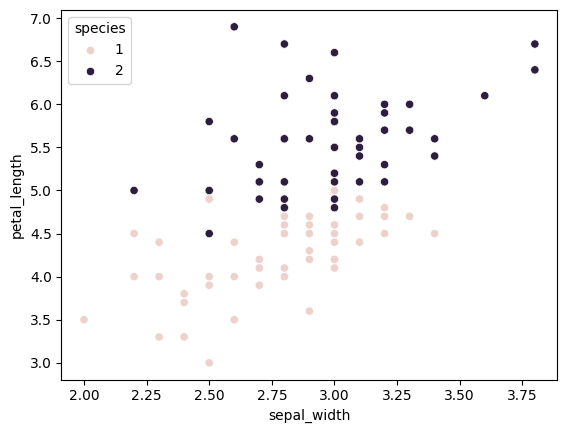

In [15]:
sns.scatterplot(data = df , x = 'sepal_width' , y = 'petal_length' , hue = 'species')
plt.show()

In [16]:
df.shape

(100, 3)

In [17]:
# sample the data(mix up rows) 
df = df.sample(100)

In [18]:
train_data = df.iloc[ : 60 , : ].sample(10)
test_data = df.iloc[60 : 80 , : ].sample(5)
validation_data = df.iloc[80 : , : ].sample(5)

In [19]:
train_data

,sepal_width,petal_length,species
135,3.0,6.1,2
100,3.3,6.0,2
83,2.7,5.1,1
149,3.0,5.1,2
99,2.8,4.1,1
129,3.0,5.8,2
54,2.8,4.6,1
67,2.7,4.1,1
137,3.1,5.5,2
119,2.2,5.0,2


In [21]:
X_test = validation_data.iloc[ : , 0 : 2].values
y_test = validation_data.iloc[ : , -1].values

In [22]:
# Data for tree 1 
df_bag = train_data.sample(n = 8 , replace = True) # duplicates are allowed

X = df_bag.iloc[ : , 0 : 2]
y = df_bag.iloc[ : , -1]
df_bag

,sepal_width,petal_length,species
119,2.2,5.0,2
54,2.8,4.6,1
67,2.7,4.1,1
99,2.8,4.1,1
135,3.0,6.1,2
54,2.8,4.6,1
99,2.8,4.1,1
99,2.8,4.1,1


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [27]:
def evaluate(clf , X , y): 
    clf.fit(X , y) 
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values , y.values , clf = clf , legend = 2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test , y_pred))

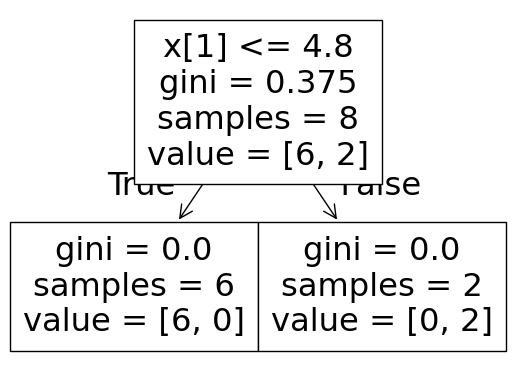

E:\Machine-Learning\Machine-Learning-Algorithms\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Machine-Learning\Machine-Learning-Algorithms\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


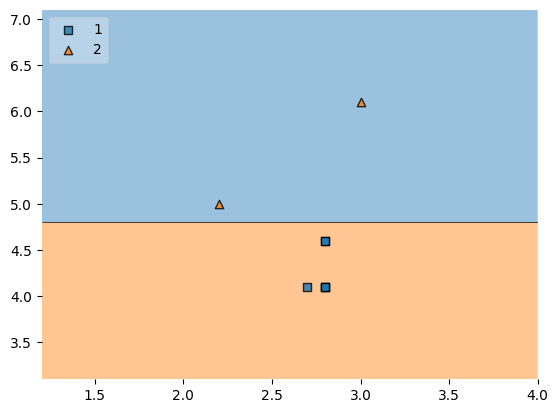

In [28]:
dt_bag1 = DecisionTreeClassifier()
evaluate(dt_bag1 , X , y)

In [29]:
# Data for tree 2 
df_bag = train_data.sample(n = 8 , replace = True) # duplicates are allowed

X = df_bag.iloc[ : , 0 : 2]
y = df_bag.iloc[ : , -1]
df_bag

,sepal_width,petal_length,species
137,3.1,5.5,2
99,2.8,4.1,1
100,3.3,6.0,2
149,3.0,5.1,2
137,3.1,5.5,2
135,3.0,6.1,2
119,2.2,5.0,2
129,3.0,5.8,2


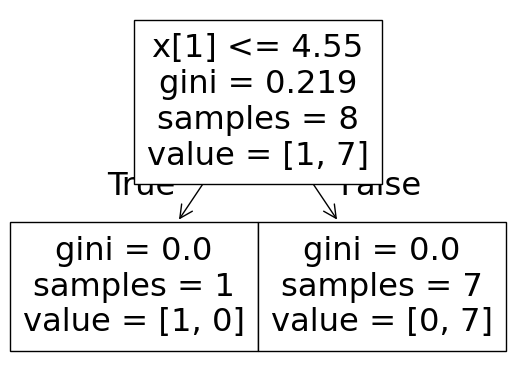

E:\Machine-Learning\Machine-Learning-Algorithms\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Machine-Learning\Machine-Learning-Algorithms\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


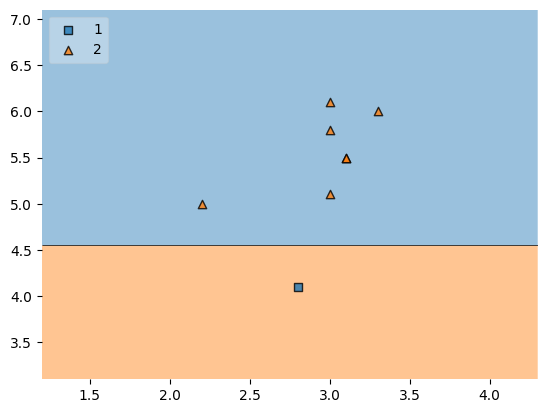

In [30]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2 , X , y)

In [31]:
# Data for tree 3 
df_bag = train_data.sample(n = 8 , replace = True) # duplicates are allowed

X = df_bag.iloc[ : , 0 : 2]
y = df_bag.iloc[ : , -1]
df_bag

,sepal_width,petal_length,species
83,2.7,5.1,1
83,2.7,5.1,1
67,2.7,4.1,1
149,3.0,5.1,2
149,3.0,5.1,2
83,2.7,5.1,1
149,3.0,5.1,2
99,2.8,4.1,1


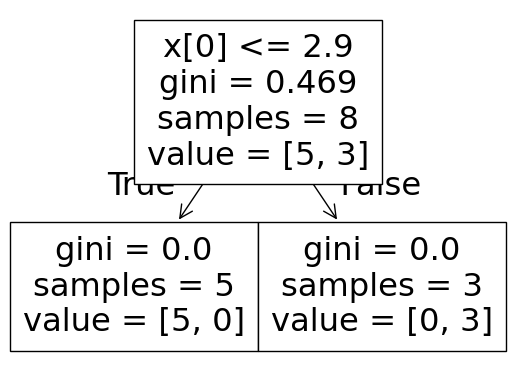

E:\Machine-Learning\Machine-Learning-Algorithms\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\Machine-Learning\Machine-Learning-Algorithms\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.4


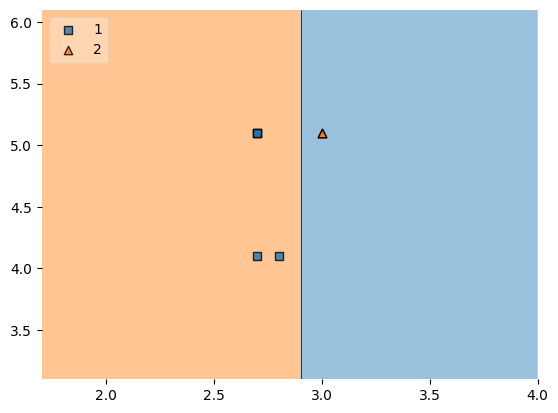

In [32]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3 , X , y)

## Prediction(Aggregation All models results)

In [33]:
test_data

,sepal_width,petal_length,species
85,3.4,4.5,1
132,2.8,5.6,2
50,3.2,4.7,1
115,3.2,5.3,2
140,3.1,5.6,2


In [35]:
import warnings
warnings.filterwarnings('ignore')

In [38]:
# predict individually 
print("Model-1" , dt_bag1.predict(np.array([3.2 , 4.7]).reshape(1 , 2)))
print("Model-2" , dt_bag2.predict(np.array([3.2 , 4.7]).reshape(1 , 2)))
print("Model-3" , dt_bag3.predict(np.array([3.2 , 4.7]).reshape(1 , 2)))

Model-1 [1]
Model-2 [2]
Model-3 [2]


##### As Majority is 2 so final prediction is class-2